In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
input_path = '/workspaces/My-warehouse/user_personalized_features.csv'
output_dir = '//workspaces/My-warehouse'

In [3]:
#数据加载与预处理函数
def load_and_preprocess(filepath):
    """数据加载与预处理"""
    df = pd.read_csv(filepath)

    # 数据质量检查
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值: {df.isnull().sum().sum()}")

    # 异常值处理
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"年龄异常值: {age_outliers}")    
    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

数据规模: 1000 行 x 15 列
缺失值: 0
年龄异常值: 0


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [4]:
#特征工程：构建优化指标
def feature_engineering(df):
    """特征工程：构建RFM-I模型所需的所有指标"""

    # 1. 基础RFM指标已在数据中

    # 2. I (Intent - 意向深度)
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1)

    # 3. L (Loyalty - 活跃连接度)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1
    df['L_Score'] = df.apply(calculate_loyalty, axis=1)

    # 4. D (Demographics - 购买力背景)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'
    df['Income_Level'] = df['Income'].apply(income_level)

    # 5. 人货匹配度
    df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    
    print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Friction 范围: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    print(f"L_Score 分布: {df['L_Score'].value_counts().to_dict()}")
    print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")
    print(f"Interest_Match 匹配率: {df['Interest_Match'].mean()*100:.1f}%")
    
    return df

df = feature_engineering(df)
df[['User_ID','I_Score','Friction','L_Score','Income_Level','Interest_Match']].head()

I_Score 范围: [0.00, 98.83]
Friction 范围: [0.10, 49.00]
L_Score 分布: {1: 824, 3: 99, 2: 77}
Income_Level 分布: {'High': 340, 'Low': 330, 'Medium': 330}
Interest_Match 匹配率: 0.0%


,User_ID,I_Score,Friction,L_Score,Income_Level,Interest_Match
0,#1,87.285385,4.750000,3,Low,0
1,#2,76.638400,5.000000,1,High,0
2,#3,25.460637,0.500000,1,High,0
3,#4,73.136516,7.250000,1,Medium,0
4,#5,13.646357,1.666667,3,Low,0


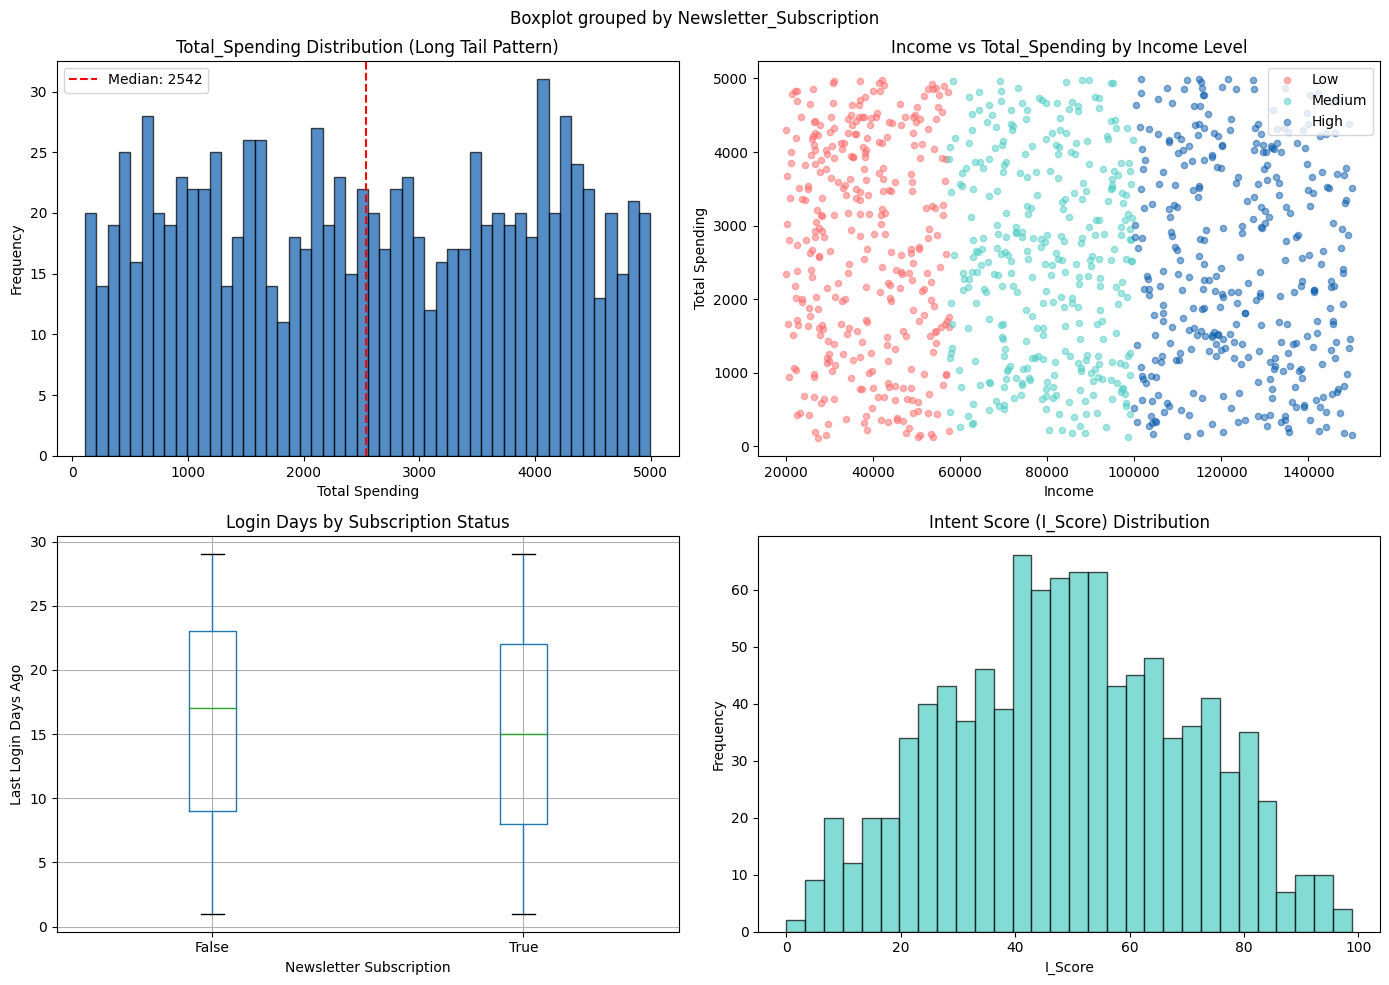

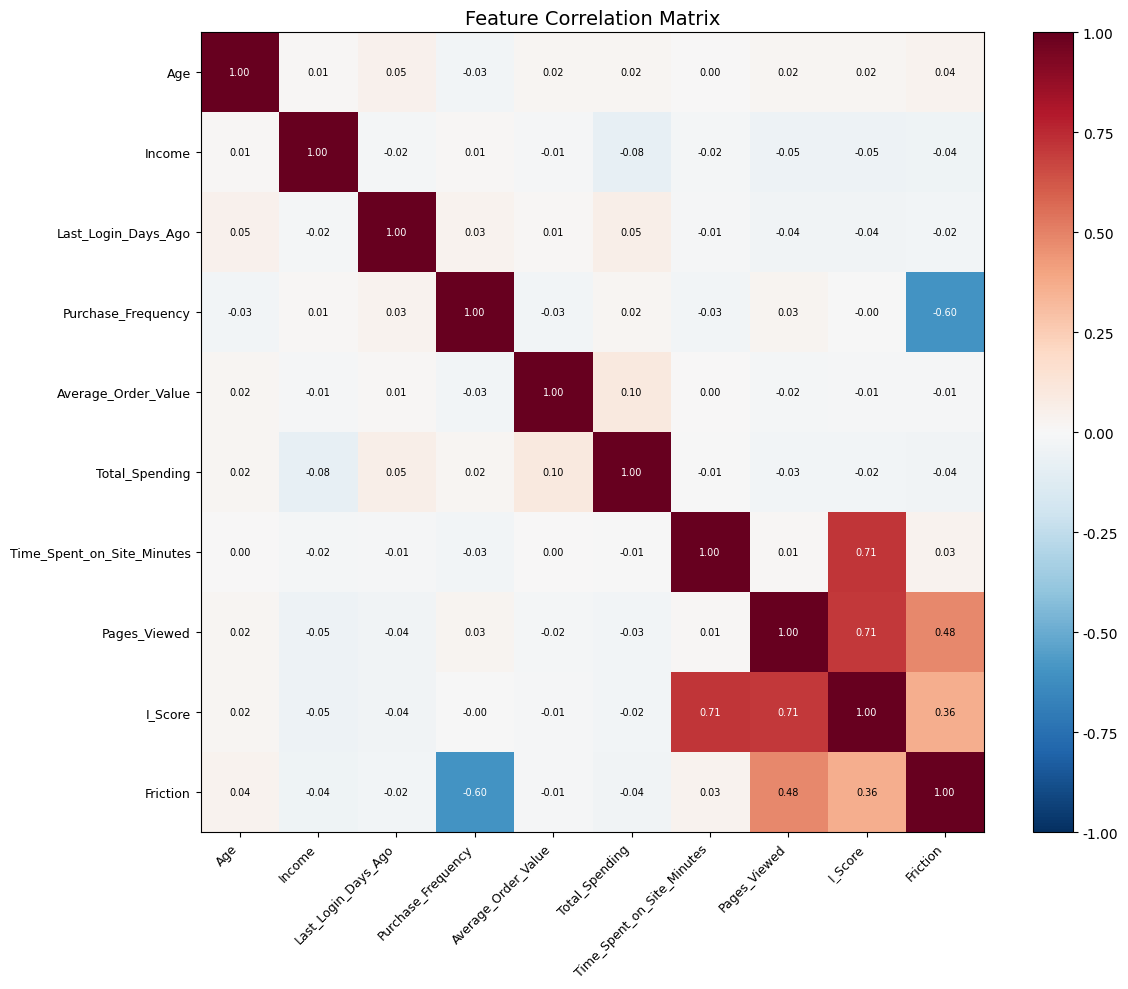


关键相关性分析:
Time_Spent vs Purchase_Frequency 相关系数: -0.028
Pages_Viewed vs Purchase_Frequency 相关系数: 0.026

高摩擦用户(前25%)特征:
  - 平均浏览页数: 34.3
  - 平均购买频率: 1.6
  - 平均消费金额: 2514

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [6]:
#EDA探索性数据分析
def perform_eda(df, output_dir):
    """EDA分析：分布、相关性、行为洞察"""

    # 1. 关键分布分析
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Total_Spending 分布
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--', 
                       label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()

    # Income vs Total_Spending 散点图
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()

    # Last_Login_Days_Ago vs Newsletter_Subscription 箱线图
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago') 

    # I_Score 分布
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. 相关性分析
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed', 'I_Score', 'Friction']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 3. 关键行为洞察
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    
    print(f"\n关键相关性分析:")
    print(f"Time_Spent vs Purchase_Frequency 相关系数: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency 相关系数: {pages_purchase_corr:.3f}")

    # 高摩擦用户分析
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\n高摩擦用户(前25%)特征:")
    print(f"  - 平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - 平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - 平均消费金额: {high_friction['Total_Spending'].mean():.0f}")

    # 高收入低消费群体
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }

eda_results = perform_eda(df, output_dir)

In [7]:
#RFM-I模型构建
def bulid_rfm_model(df):
    """构建RFM-I模型：标准化、综合得分计算"""

    #构建和前面一样的正向/反向归一化函数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100

    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'],reverse=True)
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    #进行加权得到RFM得分
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score']   #电商最经典、最通用权重
    df['I_Weight'] = df['I_Score'] / 500 #把 0~100 分的意向分 → 压缩成 0~0.2 的小权重
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight'])  #意向权重最大为0.2，可以保证模型主要以RFM得分为主，意向得分为辅助
    
    print(f'R_Score 范围:[{df['R_Score'].min().round(2)},{df['R_Score'].max().round(2)}]')
    print(f'F_Score 范围:[{df['F_Score'].min().round(2)},{df['F_Score'].max().round(2)}]')
    print(f'M_Score 范围:[{df['M_Score'].min().round(2)},{df['M_Score'].max().round(2)}]')
    print(f'RFM_Score 范围:[{df['RFM_Score'].min().round(2)},{df['RFM_Score'].max().round(2)}]')
    print(f'Final_Score 范围:[{df['Final_Score'].min().round(2)},{df['Final_Score'].max().round(2)}]')

    return df

df= bulid_rfm_model(df)
df[['User_ID','R_Score','F_Score','M_Score','I_Score','RFM_Score','Final_Score']].head()

R_Score 范围:[0.0,100.0]
F_Score 范围:[0.0,100.0]
M_Score 范围:[0.0,100.0]
RFM_Score 范围:[4.72,96.77]
Final_Score 范围:[5.26,105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


In [8]:
#用户分层与画像
def classify_users(df):
    """用户分层：基于RFM-I模型进行精细化分层"""

    def classify_user(row):
        r = row['R_Score']  #最近登录得分
        f = row['F_Score']  #购买频率得分
        m = row['M_Score']  #消费金额得分
        i = row['I_Score']  #意向深度得分，表示活跃程度，是否想要购买
        income = row['Income_Level']
        friction = row['Friction']  #摩擦指数，越大越难下单
        l = row['L_Score']

        #基础RFM模型分层逻辑：>60:高，40~60：中，<40:低
        if r > 60 and f > 60 and m > 60:    #111
            base_label = "重要价值用户"
        elif r > 60 and m > 60 and f < 40:  #101
            base_label = "重要发展用户"
        elif r < 40 and f > 60 and m > 60:  #011
            base_label = "重要保持用户"
        elif r < 40 and m > 60 :  #只要花钱花得多就要挽留，不管频率如何
            base_label = "重要挽留用户"
        elif r > 60 and f > 40 and m < 40:  #110
            base_label = "一般发展用户"
        elif r > 60 and f < 40 and m < 40:  #100
            base_label = "一般维持用户"
        elif r < 40 and f < 40 and m < 40:  #000
            base_label = "低价值用户"
        else:
            base_label = "一般用户" #还有位于40~60的得分用户，都属于一般用户

        #加入收入水平和意向深度，对用户再次细分
        if base_label in ["低价值用户", "一般维持用户"] and income == "High" and i > 60:
            return "高潜沉睡用户"
        if income == "High" and i > 70 and f < 40 and m < 50:
            return "纠结土豪"
        if base_label in ["一般维持用户", "一般发展用户"] and i > 80 and friction > df['Friction'].quantile(0.6):
            return "犹豫型潜力用户"
        if income == "Low" and i > 70 and f < 40:
            return "隐形活跃者"
        if income == "High" and r < 40 and m > 50:
            return "高潜流失客"
        if m > 70 and f > 70 and i > 60:
            return "核心VIP"
        if income == "Low" and i < 40 and m < 40:
            return "羊毛党/低值"
        
        return base_label
        
    #调用内层函数对用户进行分层
    df['User_Segment'] = df.apply(classify_user,axis=1)

    #对分层后的用户，根据他们的类型进行分组统计
    segment_stats = df.groupby(['User_Segment']).agg({'User_ID':'count','Total_Spending':'mean',
                                                      'Purchase_Frequency':'mean','I_Score':'mean','Income':'mean','Final_Score':'mean'}).round(2)
    
    #可以直接在agg函数中起列名，df.groupby('User_Segment').agg('用户数'=('User_ID','count'))
    #重命名：df.groupby('User_Segment').agg({'User_ID':'count'}).rename({'User_ID':'用户数'},axis=1)
    segment_stats.columns = ['用户数量','平均消费','平均购买次数','平均意向深度得分','平均收入','最终平均得分']
    segment_stats['占比%'] = (segment_stats['用户数量'] * 100 / len(df)).round(1)  
    segment_stats = segment_stats.sort_values('用户数量',ascending=False)

    print('用户分层统计：')
    print(segment_stats.to_string())    #将表格转化为纯文本形式输出
   
    return df, segment_stats

df, segment_stats = classify_users(df)

用户分层统计：
              用户数量     平均消费  平均购买次数  平均意向深度得分       平均收入  最终平均得分   占比%
User_Segment                                                          
一般用户           443  2368.12    5.17     48.80   84305.72   54.31  44.3
一般发展用户          81  1117.95    6.43     49.84   87107.43   52.67   8.1
重要挽留用户          67  4134.42    2.57     46.53   59698.61   58.59   6.7
高潜流失客           64  3990.70    4.92     44.09  121985.09   65.40   6.4
低价值用户           50  1036.52    1.68     42.79   94734.76   20.87   5.0
重要发展用户          48  3873.96    1.62     48.91   81230.60   65.41   4.8
一般维持用户          47  1055.40    1.47     45.83   91335.23   33.57   4.7
重要价值用户          47  3960.19    7.47     42.28   73500.94   86.82   4.7
重要保持用户          39  4030.23    7.49     48.00   57995.92   75.26   3.9
隐形活跃者           34  2756.79    1.32     77.99   36273.32   47.28   3.4
羊毛党/低值          32  1019.56    5.50     23.08   37896.19   37.05   3.2
核心VIP           23  4171.39    8.17     71.09   59382.39   88.86   2.

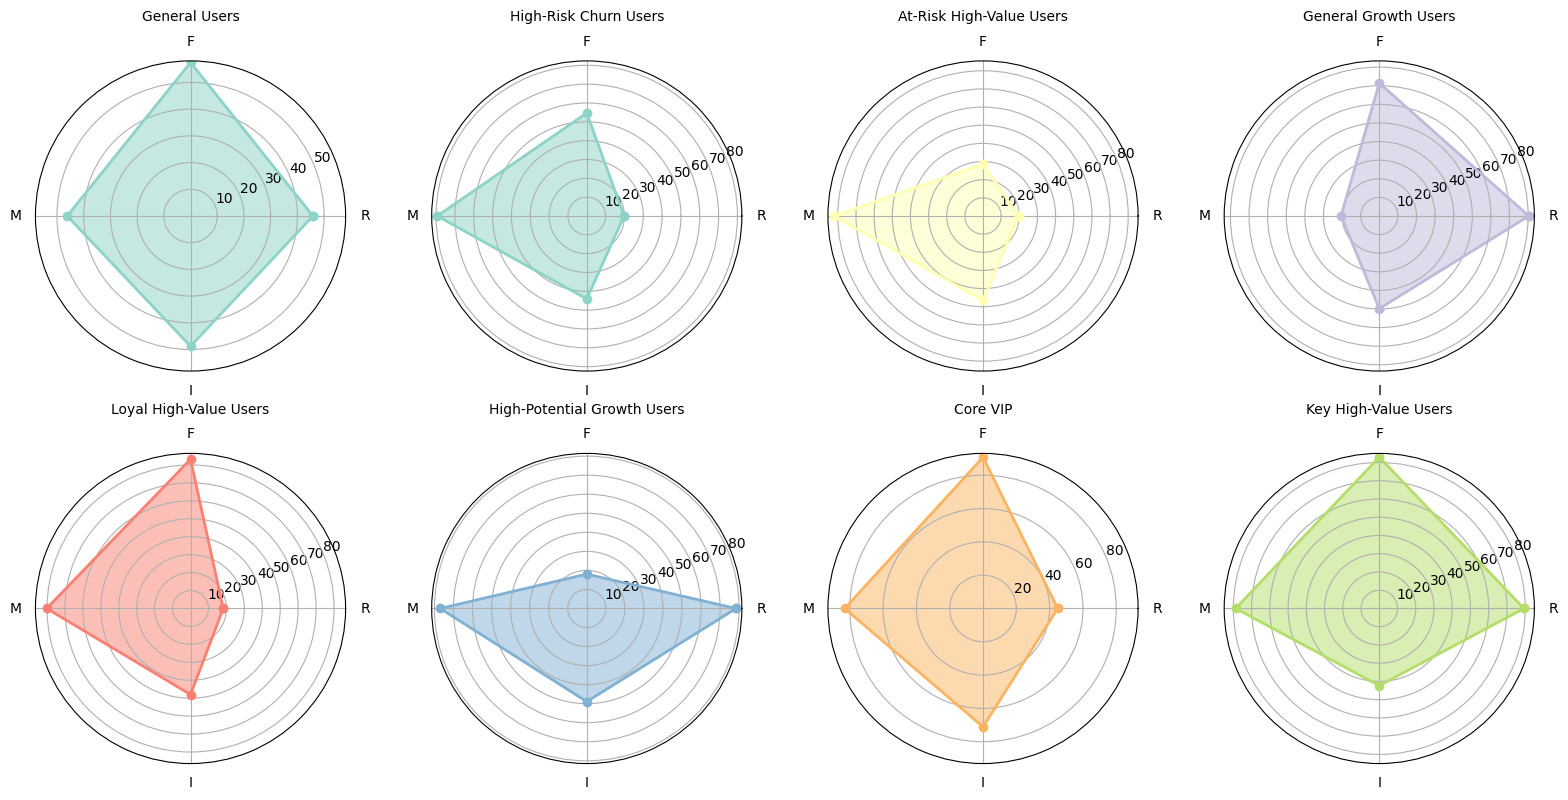

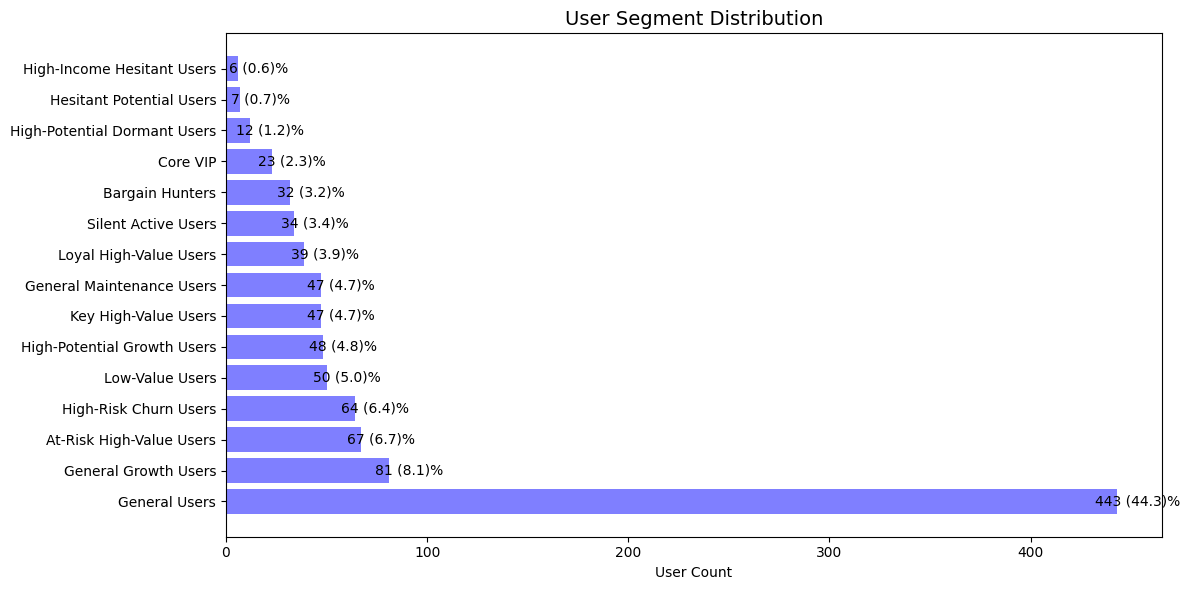

In [9]:
#对分层的用户进行用户画像可视化
def generate_segment_portrait(df,output_dir):
    """生成用户画像可视化：雷达图和分布柱状图"""

    #绘制分层雷达图
    segments = df['User_Segment'].unique()  #返回指定列中所有的不同值,返回一个列表
    segments_map = {
        "一般用户": "General Users",
        "高潜流失客": "High-Risk Churn Users",
        "重要挽留用户": "At-Risk High-Value Users",
        "一般发展用户": "General Growth Users",
        "重要保持用户": "Loyal High-Value Users",
        "重要发展用户": "High-Potential Growth Users",
        "核心VIP": "Core VIP",
        "重要价值用户": "Key High-Value Users",
        "一般维持用户": "General Maintenance Users",
        "低价值用户": "Low-Value Users",
        "羊毛党/低值": "Bargain Hunters",
        "隐形活跃者": "Silent Active Users",
        "纠结土豪": "High-Income Hesitant Users",
        "高潜沉睡用户": "High-Potential Dormant Users",
        "犹豫型潜力用户": "Hesitant Potential Users"
    }
    metrics = ['R_Score','F_Score','M_Score','I_Score']    #评价指标

    segment_means = df.groupby('User_Segment')[metrics].mean()

    #subplot_kw=dict(polar=True):把子图设置成【极坐标（雷达图专用）】
    fig, axes = plt.subplots(2, 4, figsize=(16,8), subplot_kw=dict(polar=True))
    axes = axes.flatten()   #把二维数组展平成一维，方便循环

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]    #列表+列表是直接将第二个列表的值追加在第一个列表后面

    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))  #自动分配颜色

    #绘制8张雷达图
    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]

        #填充颜色+画线
        ax.fill(angles,values,alpha=0.5,color=colors[idx])
        ax.plot(angles,values,'o-',color=colors[idx],linewidth=2)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R','F','M','I'],fontsize=10)
        ax.set_title(segments_map[segment],fontsize=10,pad=10)  #环境原因，中文无法正常显示,映射为英文

        #将多余的子图进行隐藏
    for  idx in range(len(segments),len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_rader.png',dpi=100,bbox_inches='tight')
    plt.show()
    plt.close()


    #绘制分层分布柱状图
    segment_counts = df['User_Segment'].value_counts()  #也可以使用df.groupby('User_Segment')['User_ID'].count()

    fig,ax = plt.subplots(figsize=(12,6))
    #bar绘制垂直柱状图，barh绘制水平柱状图,value_counts结果的index返回的是索引列，values返回相对应的值
    bars = ax.barh(segment_counts.index.map(segments_map),segment_counts.values,color='b',alpha=0.5)
    ax.set_xlabel('User Count')
    ax.set_title('User Segment Distribution',fontsize=14)

    for bar,count in zip(bars,segment_counts.values):
        ax.text(bar.get_width() + 10,bar.get_y() + bar.get_height()/2,
                f'{count} ({count*100/len(df):.1f})%',va='center',ha='center',fontsize=10)
        
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_distribution.png',dpi=100,bbox_inches='tight')
    plt.show()
    plt.close()

generate_segment_portrait(df,output_dir)

===假设参数===
总预算:10000元
优惠券成本:10元
平均客单价:104元
===转化率假设===
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%
===方案A-传统RFM策略===
  目标用户数: 200
  成本: 2000元
  边际收益（增量）: 2081元
  边际ROI: 4.0%
===方案B-优化RFM策略===
  核心用户: 70
  新挖掘潜力用户: 89
  总目标用户数: 159
  实际成本: 1590元 (预算使用率: 15.9%)
  边际收益（增量）: 2123元
  边际ROI: 33.5%


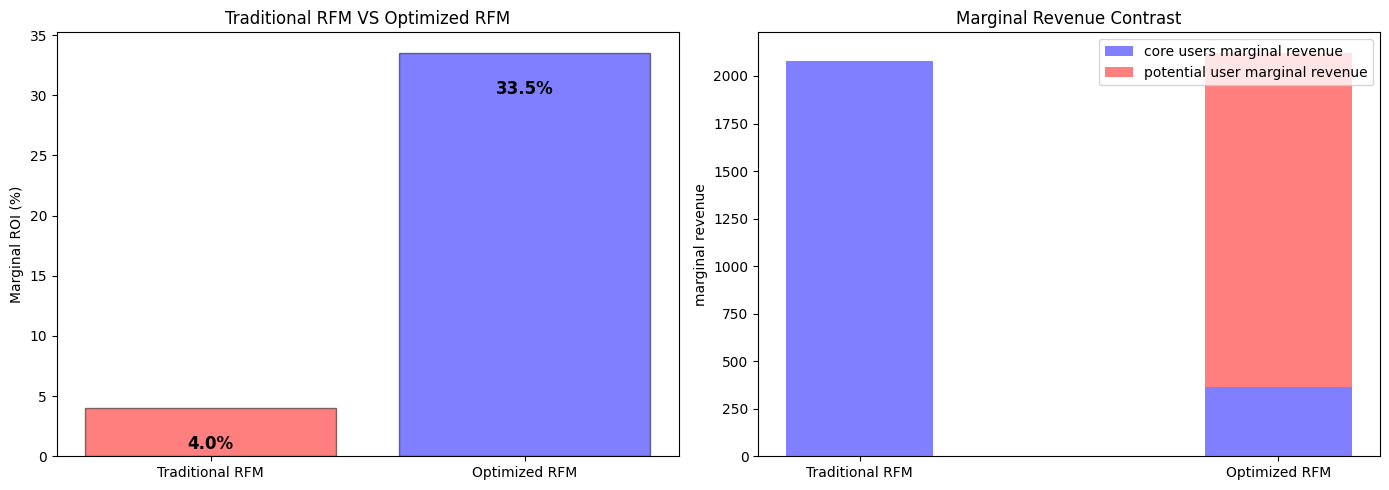

In [16]:
#投资回报率ROI测算
def calculate_roi(df,output_dir):
    """ROI测算：传统RFM vs 优化RFI策略对比（边际收益法，参数可调）"""

    #可以自行调整的参数
    total_budget = 10000    #总预算
    coupon_cost = 10    #每张优惠卷成本价格
    aov = df['Average_Order_Value'].mean()  #平均客单价

    #转化率假设:可以进行调整
    #核心用户
    core_natural = 0.25     #核心用户无券自然转化率
    core_with_coupon = 0.3  #核心用户发券之后的转化率
    #潜力用户
    potential_natural = 0.01
    potential_with_coupon = 0.2
    #一般用户(用于方案A的基线)
    general_natural = 0.02
    #RFM前20%用户的自然转化率（介于核心和一般之间）
    rfm20_natural = 0.2
    rfm20_with_coupon = 0.3

    #边际提升
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural

    #方案A：传统RFM策略
    top20_threshold = df['RFM_Score'].quantile(0.8) #80%分位数，筛选出前前20%
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]
    target_a_count = min(len(rfm_top20),total_budget // coupon_cost) #方案A优惠券最小准备数量
    cost_a = target_a_count * coupon_cost   #方案A的成本

    incremental_revenue_a = target_a_count * rfm20_lift * aov   #方案A增长的收益
    roi_a = (incremental_revenue_a - cost_a) * 100 / cost_a if cost_a > 0 else 0
    #投资回报率ROI = 总销售额/总成本    利润投资回报率=（总销售额 - 总成本）/总成本


    #方案B：优化RFM策略
    core_users = df[df['User_Segment'].isin(['核心VIP','重要价值用户'])]    #核心用户
    potential_users = df[df['User_Segment'].isin(['纠结土豪','高潜沉睡用户','犹豫型潜力用户','高潜流失客'])]

    #分配预算：优先核心用户（用80%预算），剩余给潜力用户
    core_count = min(len(core_users),int(total_budget * 0.8) // coupon_cost)
    remaining_budget = total_budget - core_count * coupon_cost
    potential_count = min(len(potential_users),remaining_budget // coupon_cost)
    target_b_count = core_count + potential_count
    cost_b = target_b_count * coupon_cost   #方案B的成本

    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) * 100 / cost_b if cost_b > 0 else 0 #方案B的利润投资回报率

    print('===假设参数===')
    print(f'总预算:{total_budget}元')
    print(f'优惠券成本:{coupon_cost}元')
    print(f'平均客单价:{aov:.0f}元')

    print('===转化率假设===')
    print(f"  RFM前20%用户：自然转化率 {rfm20_natural*100:.1f}%，发券后 {rfm20_with_coupon*100:.1f}%，边际提升 {rfm20_lift*100:.1f}%")
    print(f"  核心用户：自然转化率 {core_natural*100:.1f}%，发券后 {core_with_coupon*100:.1f}%，边际提升 {core_lift*100:.1f}%")
    print(f"  潜力用户：自然转化率 {potential_natural*100:.1f}%，发券后 {potential_with_coupon*100:.1f}%，边际提升 {potential_lift*100:.1f}%")

    print('===方案A-传统RFM策略===')
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元")
    print(f"  边际收益（增量）: {incremental_revenue_a:.0f}元")
    print(f"  边际ROI: {roi_a:.1f}%")

    print('===方案B-优化RFM策略===')
    print(f"  核心用户: {core_count}")
    print(f"  新挖掘潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(f"  实际成本: {cost_b}元 (预算使用率: {cost_b/total_budget*100:.1f}%)")
    print(f"  边际收益（增量）: {incremental_revenue_b:.0f}元")
    print(f"  边际ROI: {roi_b:.1f}%")

    #投资回报率ROI可视化对比
    fig,axes = plt.subplots(1,2,figsize=(14,5))

    #边际ROI对比
    strategies = ['Traditional RFM','Optimized RFM']
    rois = [roi_a,roi_b]
    colors = ['r','b']

    #绘制垂直柱状图
    bars = axes[0].bar(strategies,rois,color=colors,alpha=0.5,edgecolor='black')
    axes[0].set_ylabel('Marginal ROI (%)',fontsize=10)
    axes[0].set_title('Traditional RFM VS Optimized RFM',fontsize=12)
    for bar,roi in zip(bars,rois):
        axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()-3,f'{roi:.1f}%',ha='center',va='center',fontsize=12,fontweight='bold')

    #边际收益构成对比
    x = np.arange(2)
    width = 0.35

    core_marginal = [incremental_revenue_a,core_count * core_lift * aov]
    potential_marginal = [0,potential_count * potential_lift * aov]

    #绘制堆积柱状图
    axes[1].bar(x,core_marginal,width,label='core users marginal revenue',color='b',alpha=0.5)
    axes[1].bar(x,potential_marginal,width,bottom=core_marginal,label='potential user marginal revenue',color='r',alpha=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('marginal revenue')
    axes[1].set_title('Marginal Revenue Contrast',fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{output_dir}/roi_comparison.png',dpi=100,bbox_inches='tight')
    plt.show()
    plt.close()

    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b/total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }

roi_results = calculate_roi(df,output_dir)